<a href="https://colab.research.google.com/github/jupawest/SoSSProject/blob/main/voice_recognition_model_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# Importing and Installing necessary libraries
!pip install aubio ffmpeg-python soundfile matplotlib numpy

import subprocess
from pathlib import Path
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
from aubio import pitch as aubio_pitch
from IPython.display import Javascript, Audio, display
from google.colab import output, drive
from base64 import b64decode

In [27]:
"""
This code is designed for recording short voice samples in a jupyter notebook.
Converting them into a format (mono, 16kHz *.wav) suitable for speech processing
tasks like verification, transcription, or voice recognition
"""


RECORD_JS = """
const sleep = t => new Promise(r=>setTimeout(r,t));
const readBlob = b=>new Promise(r=>{
  const fr = new FileReader();
  fr.onloadend = e => r(e.target.result);
  fr.readAsDataURL(b);
});
var record = t => new Promise(async r=>{
  const stream = await navigator.mediaDevices.getUserMedia({audio:true});
  const rec = new MediaRecorder(stream);
  const chunks = [];
  rec.ondataavailable = e => chunks.push(e.data);
  rec.start();
  await sleep(t);
  rec.stop();
  rec.onstop = async () => r(await readBlob(new Blob(chunks)));
});
"""

def record_audio(sec=3, raw_fn="input.webm", wav_fn="input.wav"):
    print(f"🎯 Recording for {sec} seconds — speak now!")
    display(Javascript(RECORD_JS))
    data = output.eval_js(f'record({sec*1000})')
    binary = b64decode(data.split(',')[1])
    with open(raw_fn, 'wb') as f:
        f.write(binary)
    print("✅ Raw recording saved:", raw_fn)
    # Convert to PCM WAV at 16kHz mono
    subprocess.run([
        'ffmpeg', '-y', '-i', raw_fn,
        '-ar', '16000', '-ac', '1',
        wav_fn
    ], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    print("✅ Converted to WAV:", wav_fn)
    return wav_fn

In [28]:
# Mount Google Drive
drive.mount('/content/drive')
audio_dir = Path("/content/drive/MyDrive")
formats = ["*.wav", "*.m4a", "*.mp3", "*.flac", "*.ogg"]
audio_files = []
for ext in formats:
    audio_files.extend(audio_dir.glob(ext))
print("Found drive files:", [f.name for f in audio_files])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found drive files: ['Third Voice Check_std.wav', 'First Voice Check_std.wav', 'Second Voice Check_std.wav', 'First Voice Check.m4a', 'Second Voice Check.m4a', 'Third Voice Check.m4a']


In [29]:
def convert_to_wav(p): # Convert the input to a Path object for easy file path manipulation
    p = Path(p)
    if p.suffix.lower() != '.wav': # Check if the file extension is NOT '.wav' (case insensitive)
        out = p.with_name(p.stem + '_std.wav')
        subprocess.run(
            ['ffmpeg', '-y', '-i', str(p), '-ar', '16000', '-ac', '1', str(out)],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
        )
        return out

    return p #If it's already a .wav file, return it as-is

In [30]:
# Function extracts pitch over time from an audio file using the Aubio library
def extract_pitch(path, win_s=512, hop_s=512):
    data, sr = sf.read(path)
    # Read the audio file using SoundFile (sf), returns audio data and sample rate

    data = data.astype(np.float32)
    # Ensures the audio data is in float32 format, as required by aubio

    p_o = aubio_pitch("yinfft", buf_size=win_s, hop_size=hop_s, samplerate=sr)

    # Prepares empty lists to store time and frequency values
    times, freqs = [], []


    for i in range(0, len(data) - hop_s, hop_s):
        frame = data[i:i + win_s]
        freq = p_o(frame)[0]
        times.append((i + hop_s / 2) / sr)
        freqs.append(freq)

    # Returns time and frequency arrays
    return np.array(times), np.array(freqs)

In [45]:
# Record new voice and convert
standard_input = record_audio(sec=3)

🎯 Recording for 3 seconds — speak now!


<IPython.core.display.Javascript object>

✅ Raw recording saved: input.webm
✅ Converted to WAV: input.wav


In [48]:
def process_all1():
    audio_paths = [standard_input] + [
        str(convert_to_wav(p)) for p in audio_files
    ] # Builds a list of audio files paths, which first is the user's voice recording then each audio_files, converted to standard '.wav'


    labels = ["You"] + [Path(p).stem for p in audio_paths[1:]]
    # Creates labels for each audio file
    # "You" the user and the file name (w/out extension) for the rest

    results = {}
    for path, name in zip(audio_paths, labels):
        t, f = extract_pitch(path)
        results[name] = (t, f)
    # Extracts putch over time for each audio
    # Stores time (t) and pitch (f) arrays in results under each label

    avg = {
        name: freqs[freqs > 0].mean()
        for name, (_, freqs) in results.items()
    }
    # Computes the average putch for each speaker
    # Stored in a dictionary 'avg'

    print("Average pitch (Hz):", avg)

    ref = avg.get("You")
    access_granted = False
    # Gets the reference pitch for the user
    # Starts a flag to track if any match is found

    if ref:
      # Compares each audio file pitch to the user's voice
      # Calculates percentage difference
        print("\nPercentage difference vs your pitch:")
        for name, val in avg.items():
            if name != "You":
                percent_diff = ((val - ref) / ref * 100)
                print(f"  {name}: {percent_diff:.2f}%")

                if abs(percent_diff) <= 20:  # Within ±20% margin, grants access
                    print(f"✅ {name} is a match — Access Granted")
                    access_granted = True

        if not access_granted:
            print("❌ No matching voice found — Access Denied")

    # Plotting all pitch curves over time for comparison
    plt.figure(figsize=(10, 6))
    for name, (t, f) in results.items():
        plt.plot(t, f, label=name)
    plt.xlabel("Time (s)")
    plt.ylabel("Pitch (Hz)")
    plt.title("Pitch Over Time")
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Average pitch (Hz): {'You': np.float32(972.3863), 'Third Voice Check_std': np.float32(952.5143), 'First Voice Check_std': np.float32(1036.3884), 'Second Voice Check_std': np.float32(686.13336)}

Percentage difference vs your pitch:
  Third Voice Check_std: -2.04%
✅ Third Voice Check_std is a match — Access Granted
  First Voice Check_std: 6.58%
✅ First Voice Check_std is a match — Access Granted
  Second Voice Check_std: -29.44%


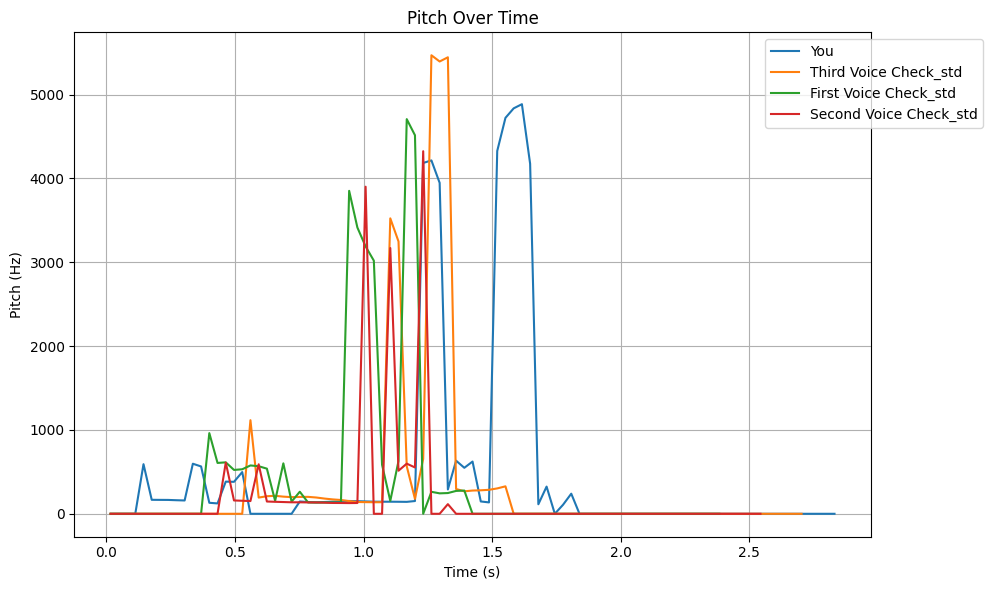

In [49]:
process_all1() # Runs functions